# Prophet Time Series Forecasting
### Goal: Use Facebook's Prophet model to forecast airline passengers

---

This notebook is the third in the series:

| Notebook | Method |
|---|---|
| Monday — ARIMA | Statistical model using past values and errors |
| Tuesday — Exponential Smoothing | Weighted averages with trend and seasonality |
| **Today — Prophet (this notebook)** | Flexible model built for real-world business data |

### What is Prophet?

Prophet is a forecasting tool created by Facebook (Meta) and released as open source in 2017.  
It was designed to handle the messy, irregular patterns found in real business data.

Prophet is especially good at:
- Detecting **trend changes** automatically (e.g. when growth speeds up or slows down)
- Handling **multiple seasonality layers** (yearly, monthly, weekly) at once
- Working even when data has **missing values or outliers**
- Producing **confidence intervals** (a range of likely outcomes, not just one number)

Github Source: https://github.com/facebook/prophet

### What we will do

1. Install and import libraries
2. Load and prepare the Airline Passengers dataset
3. Explore the data visually
4. **Part 1** — Build a Basic Prophet model with default settings
5. **Part 2** — Build an Advanced Prophet model with custom Fourier seasonality
6. **Part 3** — Compare both Prophet models against each other

### Dataset
The same **Airline Passengers** dataset used in the ARIMA and Exponential Smoothing notebooks.

---
## Step 1 — Install Libraries

In [28]:
# Prophet needs to be installed separately — it is not included by defaultt
# The exclamation mark (!) runs a terminal command from inside the notebook

!pip install prophet

# Install other libraries we need
# !pip install pandas numpy matplotlib scikit-learn

print("Installation complete!")

Installation complete!


---
## Step 2 — Import Libraries

In [29]:
# pandas — for working with tables of data
import pandas as pd

# numpy — for numerical calculations
import numpy as np

# matplotlib — for drawing charts
import matplotlib.pyplot as plt

# Prophet — the forecasting model
from prophet import Prophet

# scikit-learn — for measuring how accurate predictions are
from sklearn.metrics import mean_absolute_error, r2_score

# Hide unimportant warning messages
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


---
## Step 3 — Load and Explore the Data

We use the same Airline Passengers dataset and source link.

In [30]:
# Load the Airline Passengers dataset from the same online source as previous notebooks

url = 'https://docs.google.com/spreadsheets/d/e/2PACX-1vTD-VBPkHgph0AWNSd0ZvAyJ098KmGmGjvWaNABAr2xFpArAW3-jv0ZeU2cmolDlFLUbWqHvsnXaWML/pub?gid=1463613835&single=true&output=csv'

df = pd.read_csv(url)

print("Dataset loaded!")
print("Number of rows:", len(df))
print("Columns:", list(df.columns))
print()
print("First 5 rows:")
print(df.head())
print()
print("Basic statistics:")
print(df.describe())

Dataset loaded!
Number of rows: 144
Columns: ['Month', 'Passengers']

First 5 rows:
     Month  Passengers
0  1949-01         112
1  1949-02         118
2  1949-03         132
3  1949-04         129
4  1949-05         121

Basic statistics:
       Passengers
count  144.000000
mean   280.298611
std    119.966317
min    104.000000
25%    180.000000
50%    265.500000
75%    360.500000
max    622.000000


---
## Step 4 — Prepare the Data for Prophet

Prophet requires data in a **very specific format,** one of the most important things to get right.

The table must have exactly two columns with these exact names:

| Column name | What it contains |
|---|---|
| `ds` | The date (datestamp) |
| `y` | The value we want to forecast |

Prophet was designed around these column names. It will NOT work if they are named anything else.  
Think of it as Prophet's required "language" for reading data.

We also convert the Month column to a proper date format, same as we did in the previous notebooks.

In [31]:
# Step 4a: Convert the Month column from text to a proper date
df['Month'] = pd.to_datetime(df['Month'])

print("Date conversion done.")
print("Example:", df['Month'][0])

Date conversion done.
Example: 1949-01-01 00:00:00


In [32]:
# Step 4b: Rename columns to match Prophet's required format
# 'ds' = datestamp (the date column)
# 'y'  = the value we want to predict (passengers)

prophet_df = df.rename(columns={'Month': 'ds', 'Passengers': 'y'})

print("Columns renamed for Prophet.")
print("Date range:", prophet_df['ds'].min(), "to", prophet_df['ds'].max())
print("Total months:", len(prophet_df))
print()
print("First 5 rows in Prophet format:")
print(prophet_df.head())

Columns renamed for Prophet.
Date range: 1949-01-01 00:00:00 to 1960-12-01 00:00:00
Total months: 144

First 5 rows in Prophet format:
          ds    y
0 1949-01-01  112
1 1949-02-01  118
2 1949-03-01  132
3 1949-04-01  129
4 1949-05-01  121


---
## Step 5 — Visualise the Data

Always plot the data before building any model.  
This helps us understand what patterns Prophet will need to learn.

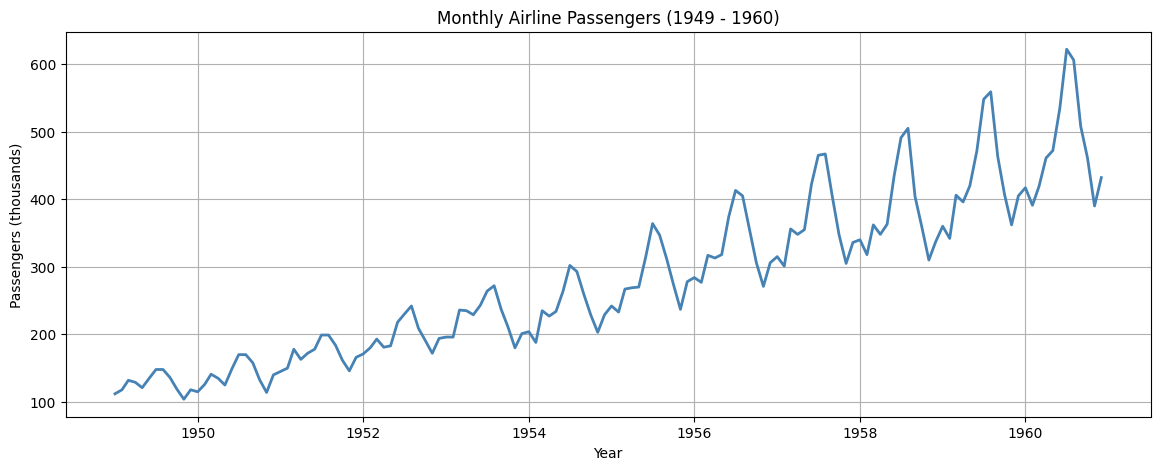

In [33]:
# Plot the full time series
plt.figure(figsize=(14, 5))
plt.plot(prophet_df['ds'], prophet_df['y'], color='steelblue', linewidth=2)
plt.title('Monthly Airline Passengers (1949 - 1960)')
plt.xlabel('Year')
plt.ylabel('Passengers (thousands)')
plt.grid(True)
plt.show()

# What to look for:
# 1. TREND — the line rises steadily over 12 years (more people flying over time)
# 2. SEASONALITY — every year peaks in summer and dips in winter
# 3. GROWING VARIANCE — the seasonal swings get larger as the trend rises
#    This last point matters: it means multiplicative seasonality fits better than additive

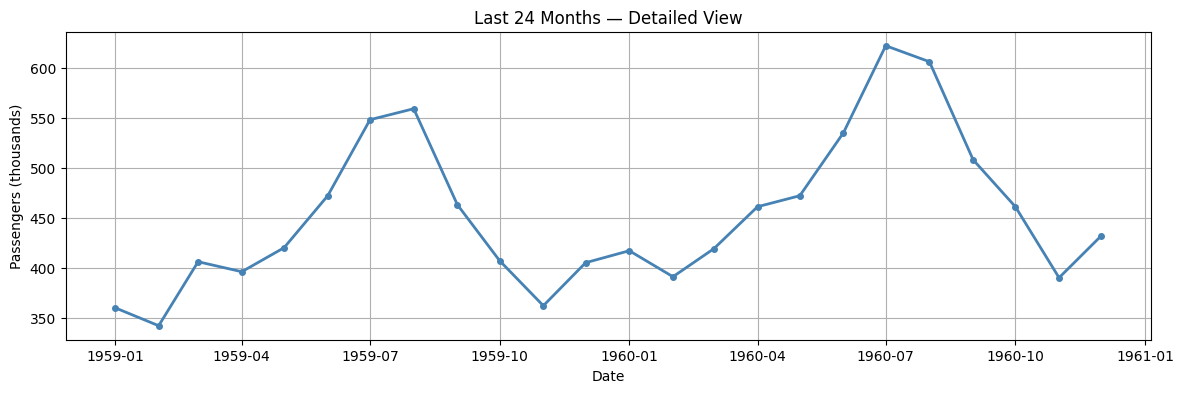

In [34]:
# Zoom into the last 24 months to see the seasonal pattern more clearly

recent = prophet_df.tail(24)

plt.figure(figsize=(14, 4))
plt.plot(recent['ds'], recent['y'], color='steelblue', linewidth=2, marker='o', markersize=4)
plt.title('Last 24 Months — Detailed View')
plt.xlabel('Date')
plt.ylabel('Passengers (thousands)')
plt.grid(True)
plt.show()

# You can clearly see the summer peak (July/August) and winter dip each year

---
## Step 6 — Train / Test Split

We hold out the last 24 months as the test set

In [35]:
# Split the data: last 24 months for testing, everything before for training

train_df = prophet_df[:-24].copy()
test_df  = prophet_df[-24:].copy()

print("Training set:", len(train_df), "months")
print("  From:", train_df['ds'].min().strftime('%Y-%m'), "to", train_df['ds'].max().strftime('%Y-%m'))
print()
print("Test set:", len(test_df), "months")
print("  From:", test_df['ds'].min().strftime('%Y-%m'), "to", test_df['ds'].max().strftime('%Y-%m'))

Training set: 120 months
  From: 1949-01 to 1958-12

Test set: 24 months
  From: 1959-01 to 1960-12


In [36]:
# Helper function to score and plot any set of predictions
# We will reuse this for both Prophet models and the comparison section

def evaluate(model_name, train_data, test_data, predictions, color='red'):
    r2  = r2_score(test_data['y'], predictions)
    mae = mean_absolute_error(test_data['y'], predictions)
    pct = (mae / test_data['y'].mean()) * 100

    plt.figure(figsize=(14, 5))
    plt.plot(train_data['ds'], train_data['y'],
             label='Training Data', color='steelblue', linewidth=2)
    plt.plot(test_data['ds'], test_data['y'],
             label='Actual (Test)', color='green', linewidth=2)
    plt.plot(test_data['ds'], predictions,
             label='Forecast', color=color, linewidth=2, linestyle='--')
    plt.title(model_name + ' — Actual vs Forecast')
    plt.xlabel('Date')
    plt.ylabel('Passengers (thousands)')
    plt.legend()
    plt.grid(True)
    plt.show()

    print("Results for:", model_name)
    print("  R² Score:", round(r2, 4), "  (closer to 1.0 is better)")
    print("  MAE:     ", round(mae, 2), "thousand passengers")
    print("  Error %: ", round(pct, 2), "% of average actual")
    print()

    return r2, mae

print("evaluate() function ready.")

evaluate() function ready.


---
## Part 1 — Basic Prophet Model

### What does the Basic Prophet model do?

The basic model uses Prophet's **default settings** to automatically detect:

| Component | What it finds |
|---|---|
| **Trend** | The general direction: Is the data going up, down, or flat? |
| **Yearly seasonality** | Patterns that repeat every 12 months |
| **Weekly seasonality** | Patterns that repeat every 7 days |
| **Changepoints** | Moments where the trend changes speed or direction |

Prophet finds all of these automatically — you do not need to specify them manually.

### Default settings Prophet uses internally
- **Changepoint prior scale**: 0.05 — controls how flexible the trend line is
- **Yearly seasonality**: 10 Fourier terms — captures yearly cycles
- **Weekly seasonality**: 3 Fourier terms — captures weekly cycles
- **Seasonality mode**: additive — seasonal effect is added to the trend

> **Note:** Our data is monthly, so weekly seasonality is not meaningful here.  
> We turn it off to keep the model focused on what matters.

### Step 7 — Train the Basic Prophet Model

In [37]:
# Create the basic Prophet model
# We turn off daily and weekly seasonality because our data is monthly — not daily

model_basic = Prophet(
    daily_seasonality=False,    # No hourly data, so daily patterns do not apply
    weekly_seasonality=False,   # Monthly data — no day-of-week pattern
    yearly_seasonality=True,    # Detect patterns that repeat every 12 months
    seasonality_mode='additive' # Seasonal effect adds to the trend (we will compare with multiplicative later)
)

print("Basic Prophet model created.")
print("Next: fit (train) the model on the training data...")

Basic Prophet model created.
Next: fit (train) the model on the training data...


In [38]:
# Fit (train) the model on the training data
# Prophet reads the 'ds' and 'y' columns automatically

model_basic.fit(train_df)

print("Basic Prophet model trained successfully!")
print()
print("Prophet has now learned:")
print("  - The overall trend direction")
print("  - The yearly seasonal pattern")
print("  - Any changepoints where the trend shifted")

17:12:44 - cmdstanpy - INFO - Chain [1] start processing
17:12:44 - cmdstanpy - INFO - Chain [1] done processing


Basic Prophet model trained successfully!

Prophet has now learned:
  - The overall trend direction
  - The yearly seasonal pattern
  - Any changepoints where the trend shifted


### Step 8 — Make Predictions with the Basic Model

Prophet forecasts in two steps:
1. **Create a future dataframe** — a table of dates we want predictions for
2. **Call predict()** — Prophet fills in a forecast for each date

The forecast table includes:
- `yhat` — the predicted value (our best estimate)
- `yhat_lower` — the lower edge of the confidence interval
- `yhat_upper` — the upper edge of the confidence interval
- `trend`, `yearly` — the individual components

In [39]:
# Step 1: Create a table of future dates
# make_future_dataframe includes both the historical dates AND the new future dates
# periods=24 means predict 24 months ahead (matching our test set)

future_basic = model_basic.make_future_dataframe(periods=24, freq='MS')
# 'MS' = Month Start — one row per month

print("Future dataframe created.")
print("Total rows (historical + future):", len(future_basic))
print("Last historical date:", train_df['ds'].max().strftime('%Y-%m'))
print("Last forecast date:  ", future_basic['ds'].max().strftime('%Y-%m'))

Future dataframe created.
Total rows (historical + future): 144
Last historical date: 1958-12
Last forecast date:   1960-12


In [40]:
# Step 2: Generate the forecast
forecast_basic = model_basic.predict(future_basic)

print("Forecast generated!")
print()
print("Forecast columns available:")
print(list(forecast_basic.columns))
print()
print("Last 6 rows of forecast (the future predictions):")
print(forecast_basic[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(6))

Forecast generated!

Forecast columns available:
['ds', 'trend', 'yhat_lower', 'yhat_upper', 'trend_lower', 'trend_upper', 'additive_terms', 'additive_terms_lower', 'additive_terms_upper', 'yearly', 'yearly_lower', 'yearly_upper', 'multiplicative_terms', 'multiplicative_terms_lower', 'multiplicative_terms_upper', 'yhat']

Last 6 rows of forecast (the future predictions):
            ds        yhat  yhat_lower  yhat_upper
138 1960-07-01  518.254197  495.395816  541.040900
139 1960-08-01  521.787299  498.154360  545.453439
140 1960-09-01  482.138155  457.162215  507.676269
141 1960-10-01  449.809109  427.886887  471.861195
142 1960-11-01  421.615207  399.693848  446.407178
143 1960-12-01  447.879442  424.232586  472.016153


### Step 9 — Visualise Basic Model Results

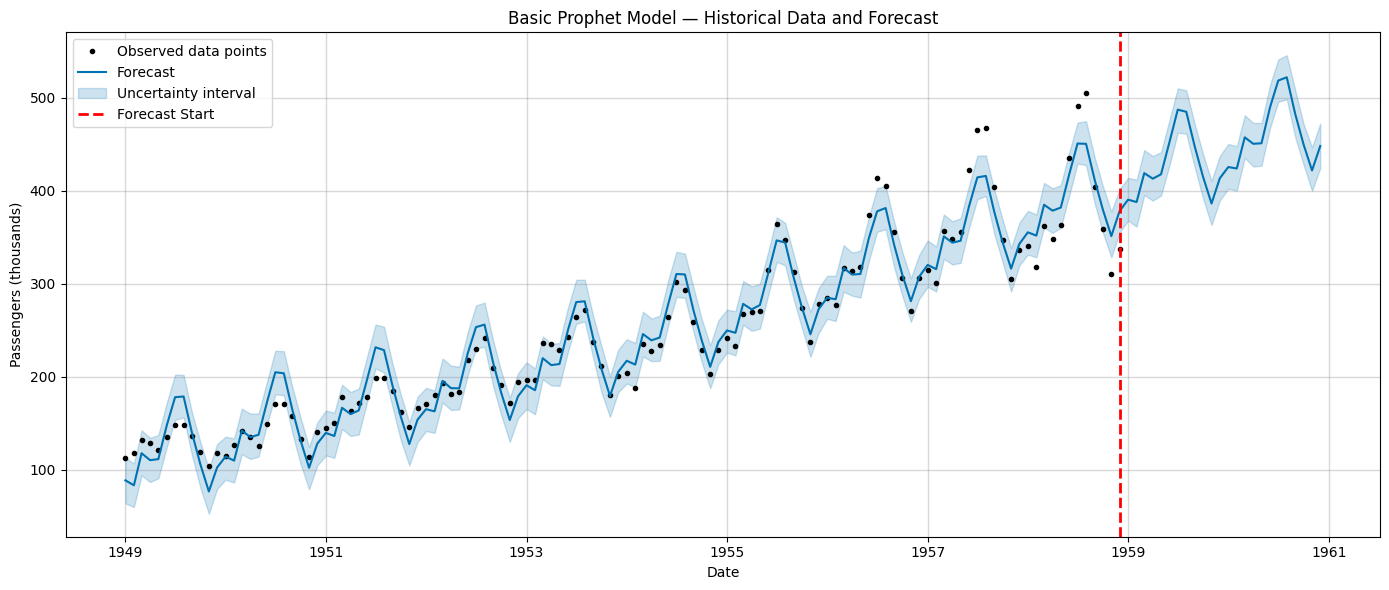

How to read this chart:
  Black dots    = actual historical passenger counts
  Blue line     = Prophet's fitted line and forecast
  Light blue    = confidence interval (80% chance the real value falls here)
  Red dashed    = where the forecast period begins


In [41]:
# Prophet has a built-in plot method
# Black dots = actual historical data
# Blue line  = model's fitted values + forecast
# Light blue = confidence interval (uncertainty range)

fig = model_basic.plot(forecast_basic, figsize=(14, 6))
plt.title('Basic Prophet Model — Historical Data and Forecast')
plt.xlabel('Date')
plt.ylabel('Passengers (thousands)')

# Add a vertical line to show where the forecast begins
plt.axvline(x=train_df['ds'].max(), color='red', linestyle='--', linewidth=2, label='Forecast Start')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("How to read this chart:")
print("  Black dots    = actual historical passenger counts")
print("  Blue line     = Prophet's fitted line and forecast")
print("  Light blue    = confidence interval (80% chance the real value falls here)")
print("  Red dashed    = where the forecast period begins")

### Step 10 — Analyse the Components (Basic Model)

One of Prophet's best features is that it shows you **exactly what it learned** broken into separate charts for each component.

This is similar to the decomposition we did in the ARIMA notebook, but Prophet does it automatically as part of the model.

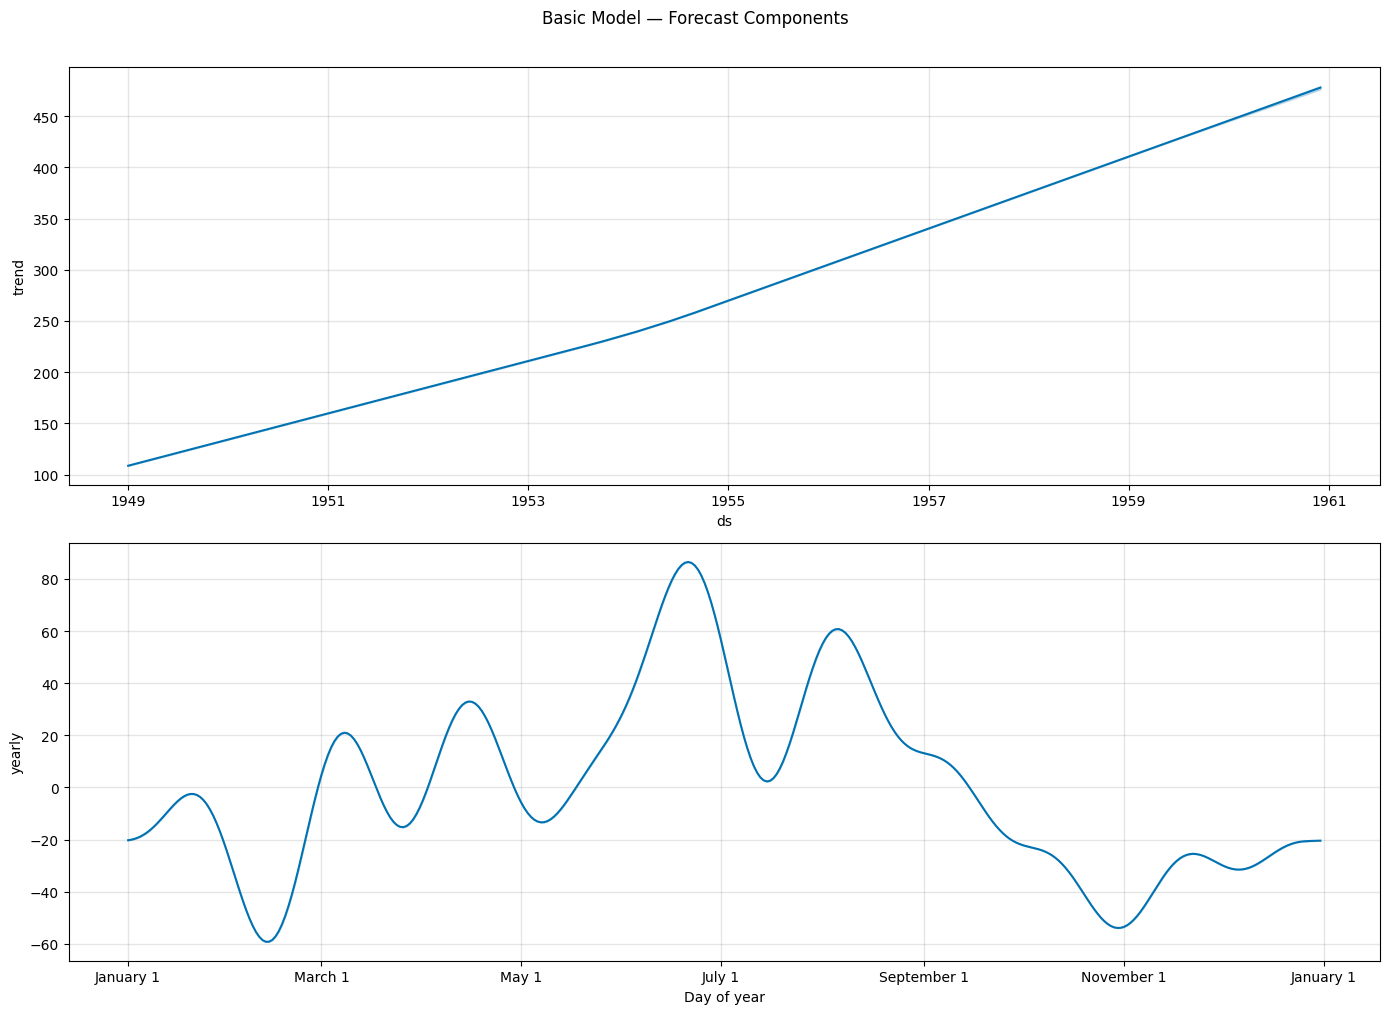

How to read each component:

TREND:
  Shows the overall direction — are passengers growing over time?
  Changepoints are where the trend shifts speed or direction

YEARLY:
  Shows which months have higher or lower passengers than average
  Peaks in summer, dips in winter — exactly what we saw in the raw data


In [42]:
# Prophet's component plot shows each learned pattern separately

fig = model_basic.plot_components(forecast_basic, figsize=(14, 10))
plt.suptitle('Basic Model — Forecast Components', y=1.01)
plt.tight_layout()
plt.show()

print("How to read each component:")
print()
print("TREND:")
print("  Shows the overall direction — are passengers growing over time?")
print("  Changepoints are where the trend shifts speed or direction")
print()
print("YEARLY:")
print("  Shows which months have higher or lower passengers than average")
print("  Peaks in summer, dips in winter — exactly what we saw in the raw data")

### Step 11 — Evaluate the Basic Model on the Test Set

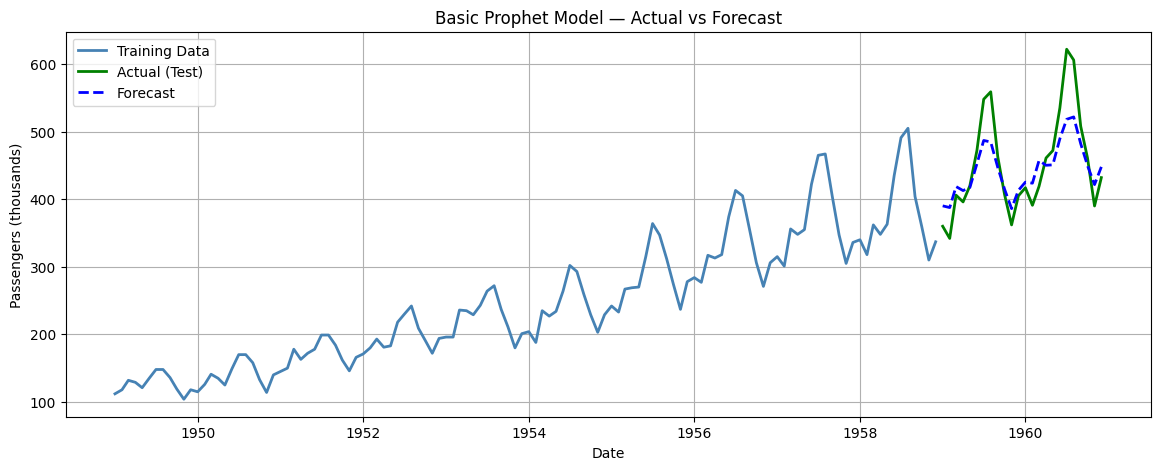

Results for: Basic Prophet Model
  R² Score: 0.7073   (closer to 1.0 is better)
  MAE:      31.16 thousand passengers
  Error %:  6.89 % of average actual



In [ ]:
# Extract only the forecast for the test period (the 24 months we held out)
last_train_date = train_df['ds'].max()
forecast_basic_test = forecast_basic[forecast_basic['ds'] > last_train_date].copy()

# Align the predictions with the test set
basic_predictions = forecast_basic_test['yhat'].values

# Me: In above line, .values converts the pandas Series to a NumPy array, which is needed for 
# the evaluation function that compares predictions against actual test values.


# Score and plot
r2_basic, mae_basic = evaluate(
    'Basic Prophet Model',
    train_df, test_df,
    basic_predictions,
    color='blue'
)

# in above code, we use train_df only for the following plot. We do not use it for finding
# the scores and evaluation.

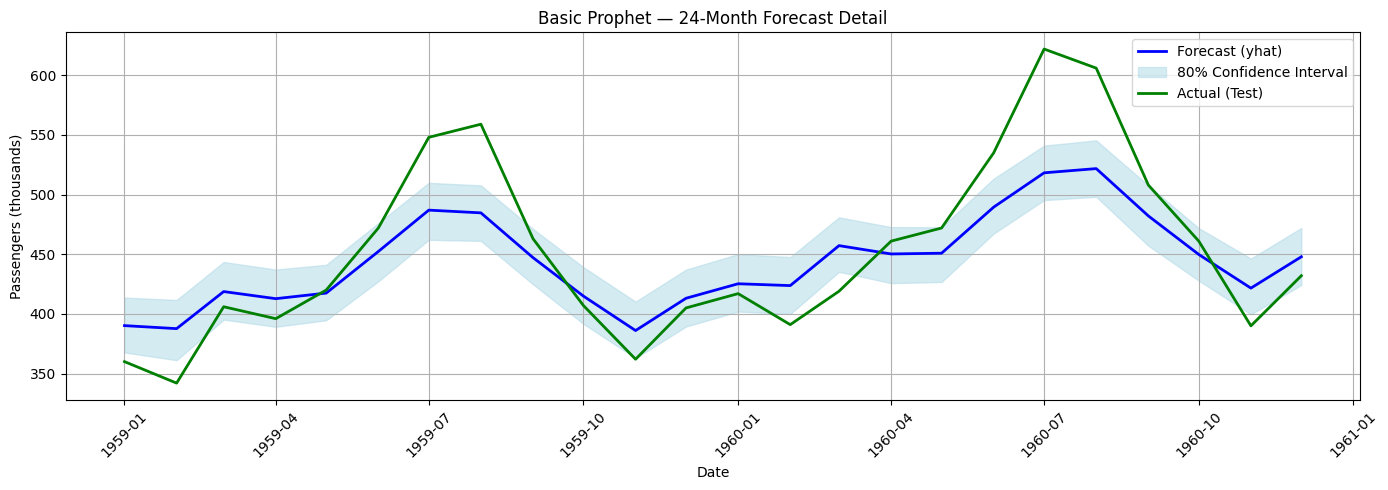

Forecast Summary — Basic Model:
  Average predicted: 443.8 thousand passengers
  Minimum predicted: 386.1
  Maximum predicted: 521.8


In [44]:
# Zoom into the forecast period only, showing the confidence interval

forecast_period = forecast_basic[forecast_basic['ds'] > last_train_date]

plt.figure(figsize=(14, 5))
plt.plot(forecast_period['ds'], forecast_period['yhat'],
         color='blue', linewidth=2, label='Forecast (yhat)')
plt.fill_between(forecast_period['ds'],
                 forecast_period['yhat_lower'],
                 forecast_period['yhat_upper'],
                 color='lightblue', alpha=0.5, label='80% Confidence Interval')
plt.plot(test_df['ds'], test_df['y'],
         color='green', linewidth=2, label='Actual (Test)')

plt.title('Basic Prophet — 24-Month Forecast Detail')
plt.xlabel('Date')
plt.ylabel('Passengers (thousands)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Summary numbers
print("Forecast Summary — Basic Model:")
print("  Average predicted:", round(forecast_period['yhat'].mean(), 1), "thousand passengers")
print("  Minimum predicted:", round(forecast_period['yhat'].min(), 1))
print("  Maximum predicted:", round(forecast_period['yhat'].max(), 1))

---
## Part 2 — Advanced Prophet with Custom Fourier Seasonality

### What is Fourier Seasonality?

Prophet models seasonal patterns using **Fourier terms** — a mathematical technique  
that combines multiple wave shapes to capture complex repeating patterns.

Think of it like this:
- A simple seasonal pattern (e.g. one big summer peak) can be drawn with just a few waves
- A complex pattern (e.g. multiple peaks and dips throughout the year) needs many waves layered together

The **Fourier order** controls how many waves are combined:

| Fourier Order | Pattern complexity | Risk |
|---|---|---|
| Low (e.g. 3) | Simple — one or two bumps per cycle | May miss detail |
| Medium (e.g. 10) | Moderate — default Prophet setting | Good balance |
| High (e.g. 20) | Complex — many bumps per cycle | Risk of overfitting |

**Overfitting warning:** If the Fourier order is too high, the model starts memorising  
the noise in the training data instead of learning the true pattern.  
Always check the test set score, not just how well it fits the training data.

### What we change in the Advanced model

| Setting | Basic model | Advanced model |
|---|---|---|
| Yearly seasonality | 10 Fourier terms (default) | 20 Fourier terms (more detail) |
| Weekly seasonality | Off | Off (monthly data — not relevant) |
| Monthly seasonality | Not included | Added as a custom component |
| Seasonality mode | Additive | Multiplicative (better for growing variance) |

**Why multiplicative?**  
In our data the seasonal swings grow larger as the trend rises — the same pattern  
we identified in the Exponential Smoothing notebook when we chose multiplicative Holt-Winters.

### Step 12 — Build the Advanced Model

In [45]:
# Create the advanced model
# We turn off automatic seasonality so we can add our own custom versions

model_advanced = Prophet(
    daily_seasonality=False,
    weekly_seasonality=False,   # We add this manually below with a higher Fourier order
    yearly_seasonality=False,   # We add this manually below with a higher Fourier order
    seasonality_mode='multiplicative'  # Better for data where seasonal swings grow over time
)

print("Advanced Prophet model created (no automatic seasonality yet).")
print("Now adding custom seasonality components...")

Advanced Prophet model created (no automatic seasonality yet).
Now adding custom seasonality components...


In [46]:
# Add custom yearly seasonality with a higher Fourier order
# period=365.25 = number of days in a year (365.25 accounts for leap years)
# fourier_order=20 = more wave terms = more complex yearly pattern captured

model_advanced.add_seasonality(
    name='yearly_custom',
    period=365.25,
    fourier_order=20
)

print("Custom yearly seasonality added (Fourier order 20 vs default 10)")

Custom yearly seasonality added (Fourier order 20 vs default 10)


In [47]:
# Add custom monthly seasonality — a new component not in the basic model
# period=30.5 = approximate number of days in a month
# fourier_order=8 = captures within-month patterns

model_advanced.add_seasonality(
    name='monthly_custom',
    period=30.5,
    fourier_order=8
)

print("Custom monthly seasonality added (new — not in basic model)")
print()
print("Summary of seasonality components in the advanced model:")
print("  yearly_custom  — period=365.25 days, Fourier order=20")
print("  monthly_custom — period=30.5 days,  Fourier order=8")

Custom monthly seasonality added (new — not in basic model)

Summary of seasonality components in the advanced model:
  yearly_custom  — period=365.25 days, Fourier order=20
  monthly_custom — period=30.5 days,  Fourier order=8


### Step 13 — Train the Advanced Model

In [48]:
# Fit the advanced model on the same training data
print("Training the advanced model...")

model_advanced.fit(train_df)

print("Advanced Prophet model trained successfully!")

17:12:45 - cmdstanpy - INFO - Chain [1] start processing
17:12:45 - cmdstanpy - INFO - Chain [1] done processing


Training the advanced model...
Advanced Prophet model trained successfully!


### Step 14 — Make Predictions with the Advanced Model

In [49]:
# Create future dates — same 24-month horizon as before
future_advanced = model_advanced.make_future_dataframe(periods=24, freq='MS')

# Generate the forecast
forecast_advanced = model_advanced.predict(future_advanced)

print("Advanced forecast generated!")
print()
print("Last 6 rows of forecast:")
print(forecast_advanced[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(6))

Advanced forecast generated!

Last 6 rows of forecast:
            ds        yhat  yhat_lower  yhat_upper
138 1960-07-01  577.588767  563.793584  591.242990
139 1960-08-01  537.835802  523.377030  551.700475
140 1960-09-01  431.431418  418.759482  443.203753
141 1960-10-01  350.729643  339.227764  362.247168
142 1960-11-01  280.533864  270.483352  290.558774
143 1960-12-01  332.829298  320.512407  344.583806


### Step 15 — Visualise Advanced Model Results

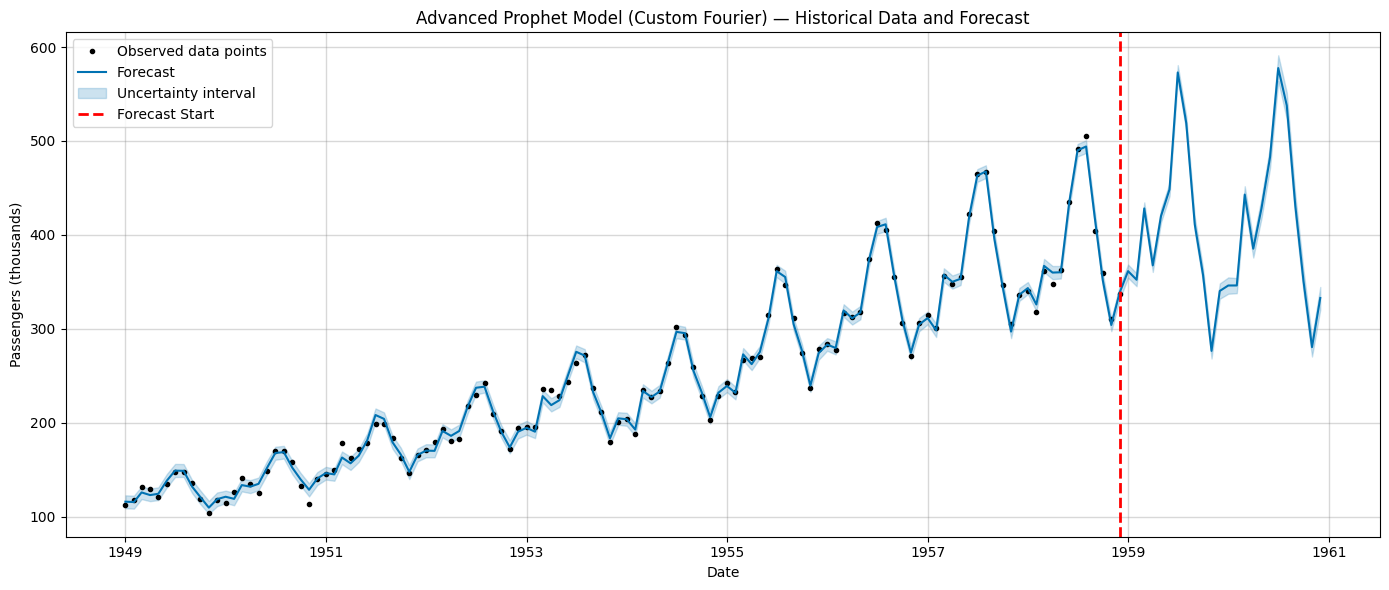

Compare this chart to the Basic Model chart above.
Look for differences in how closely the line follows the historical dots.


In [50]:
# Built-in Prophet plot for the advanced model
fig = model_advanced.plot(forecast_advanced, figsize=(14, 6))
plt.title('Advanced Prophet Model (Custom Fourier) — Historical Data and Forecast')
plt.xlabel('Date')
plt.ylabel('Passengers (thousands)')
plt.axvline(x=train_df['ds'].max(), color='red', linestyle='--', linewidth=2, label='Forecast Start')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Compare this chart to the Basic Model chart above.")
print("Look for differences in how closely the line follows the historical dots.")

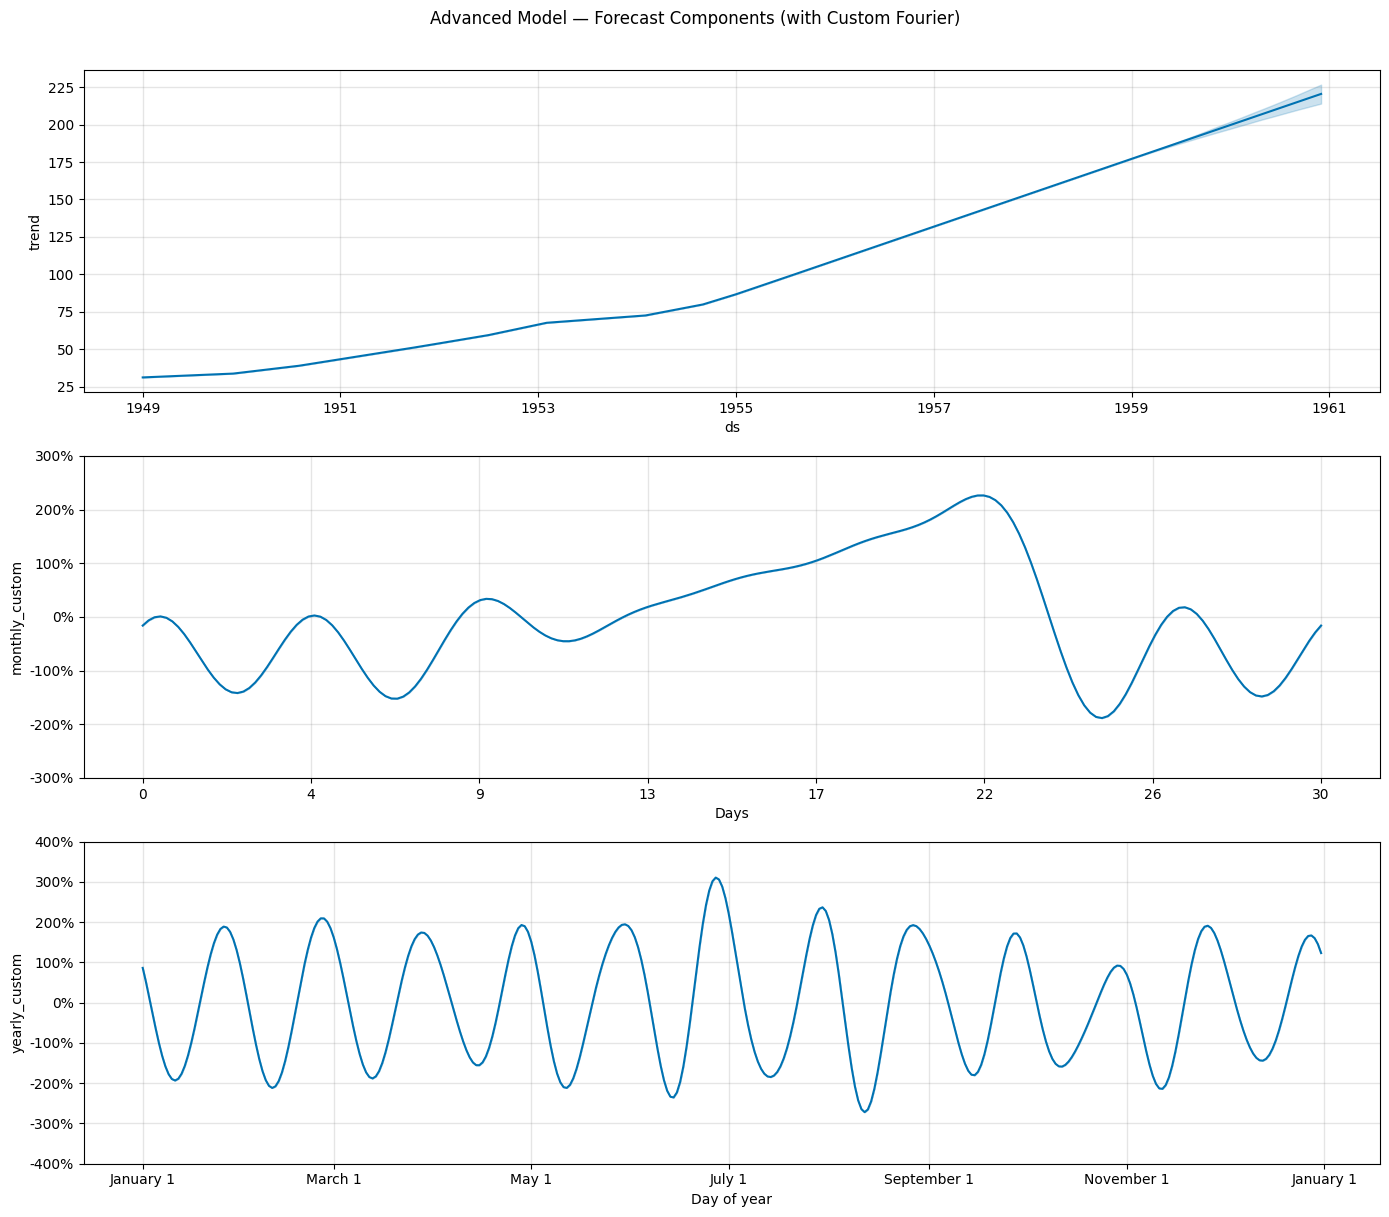

What is new compared to the Basic Model components:

YEARLY_CUSTOM (Fourier order 20):
  More detailed curves — can show multiple peaks and dips within a year
  Compare to basic model's yearly chart — the shape may be more complex here

MONTHLY_CUSTOM (new component):
  Shows patterns within each month
  Useful if sales tend to spike at the start or end of the month


In [51]:
# Component breakdown for the advanced model
# Notice: we now have an extra chart for the monthly_custom component

fig = model_advanced.plot_components(forecast_advanced, figsize=(14, 12))
plt.suptitle('Advanced Model — Forecast Components (with Custom Fourier)', y=1.01)
plt.tight_layout()
plt.show()

print("What is new compared to the Basic Model components:")
print()
print("YEARLY_CUSTOM (Fourier order 20):")
print("  More detailed curves — can show multiple peaks and dips within a year")
print("  Compare to basic model's yearly chart — the shape may be more complex here")
print()
print("MONTHLY_CUSTOM (new component):")
print("  Shows patterns within each month")
print("  Useful if sales tend to spike at the start or end of the month")

### Step 16 — Evaluate the Advanced Model on the Test Set

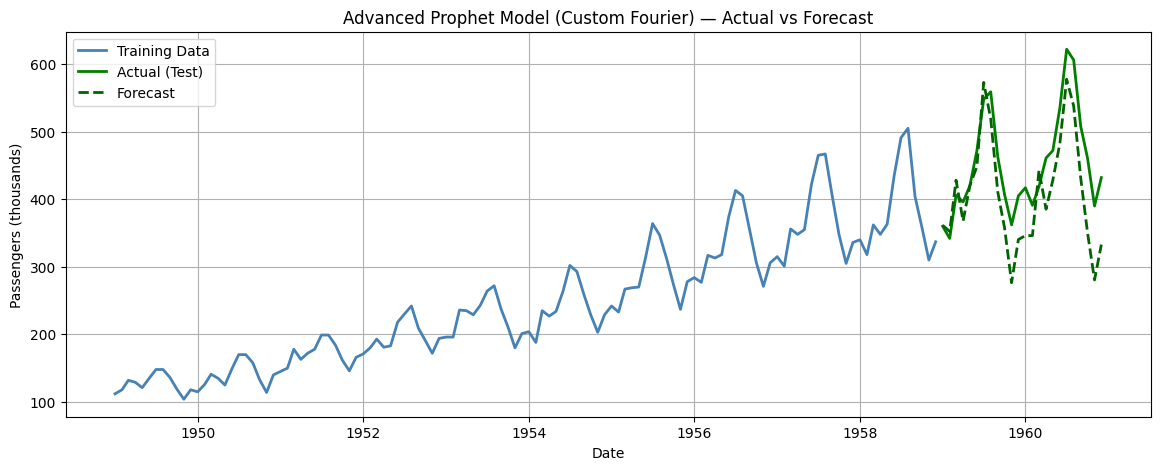

Results for: Advanced Prophet Model (Custom Fourier)
  R² Score: 0.3628   (closer to 1.0 is better)
  MAE:      50.92 thousand passengers
  Error %:  11.26 % of average actual



In [52]:
# Extract the advanced model's predictions for the test period
forecast_advanced_test = forecast_advanced[forecast_advanced['ds'] > last_train_date].copy()
advanced_predictions = forecast_advanced_test['yhat'].values

# Score and plot
r2_advanced, mae_advanced = evaluate(
    'Advanced Prophet Model (Custom Fourier)',
    train_df, test_df,
    advanced_predictions,
    color='darkgreen'
)

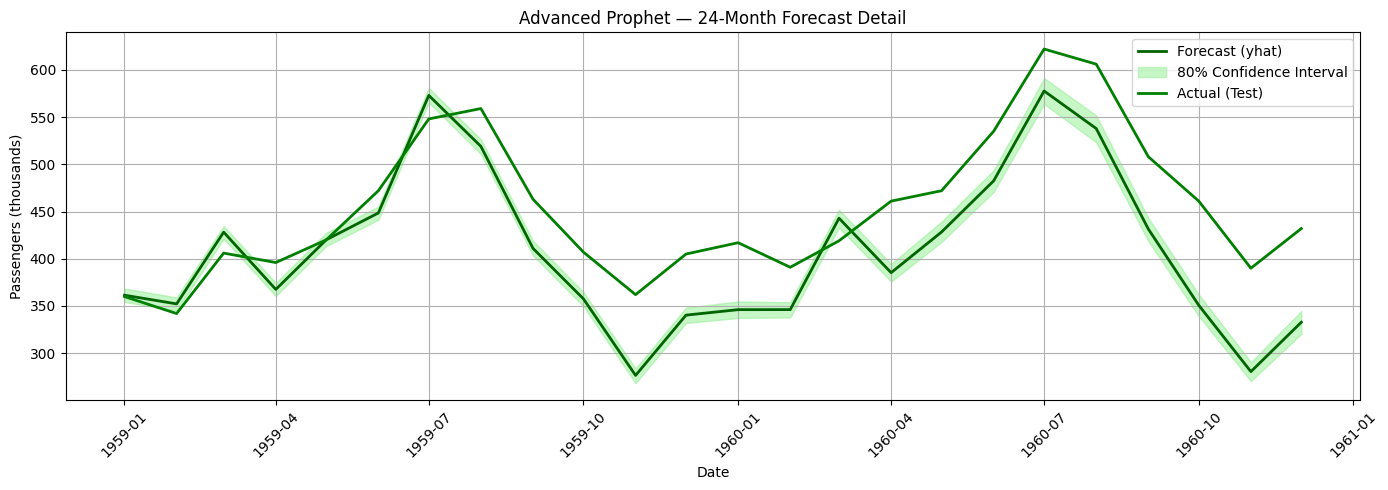

Forecast Summary — Advanced Model:
  Average predicted: 408.2 thousand passengers
  Minimum predicted: 276.5
  Maximum predicted: 577.6


In [53]:
# Zoom into the forecast period with confidence interval

forecast_period_adv = forecast_advanced[forecast_advanced['ds'] > last_train_date]

plt.figure(figsize=(14, 5))
plt.plot(forecast_period_adv['ds'], forecast_period_adv['yhat'],
         color='darkgreen', linewidth=2, label='Forecast (yhat)')
plt.fill_between(forecast_period_adv['ds'],
                 forecast_period_adv['yhat_lower'],
                 forecast_period_adv['yhat_upper'],
                 color='lightgreen', alpha=0.5, label='80% Confidence Interval')
plt.plot(test_df['ds'], test_df['y'],
         color='green', linewidth=2, label='Actual (Test)')

plt.title('Advanced Prophet — 24-Month Forecast Detail')
plt.xlabel('Date')
plt.ylabel('Passengers (thousands)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Forecast Summary — Advanced Model:")
print("  Average predicted:", round(forecast_period_adv['yhat'].mean(), 1), "thousand passengers")
print("  Minimum predicted:", round(forecast_period_adv['yhat'].min(), 1))
print("  Maximum predicted:", round(forecast_period_adv['yhat'].max(), 1))

---
## Part 3 — Comparison: Basic vs Advanced

Compare the two methods on the same data and the same test period.

### Step 17 — Plot All Models Together

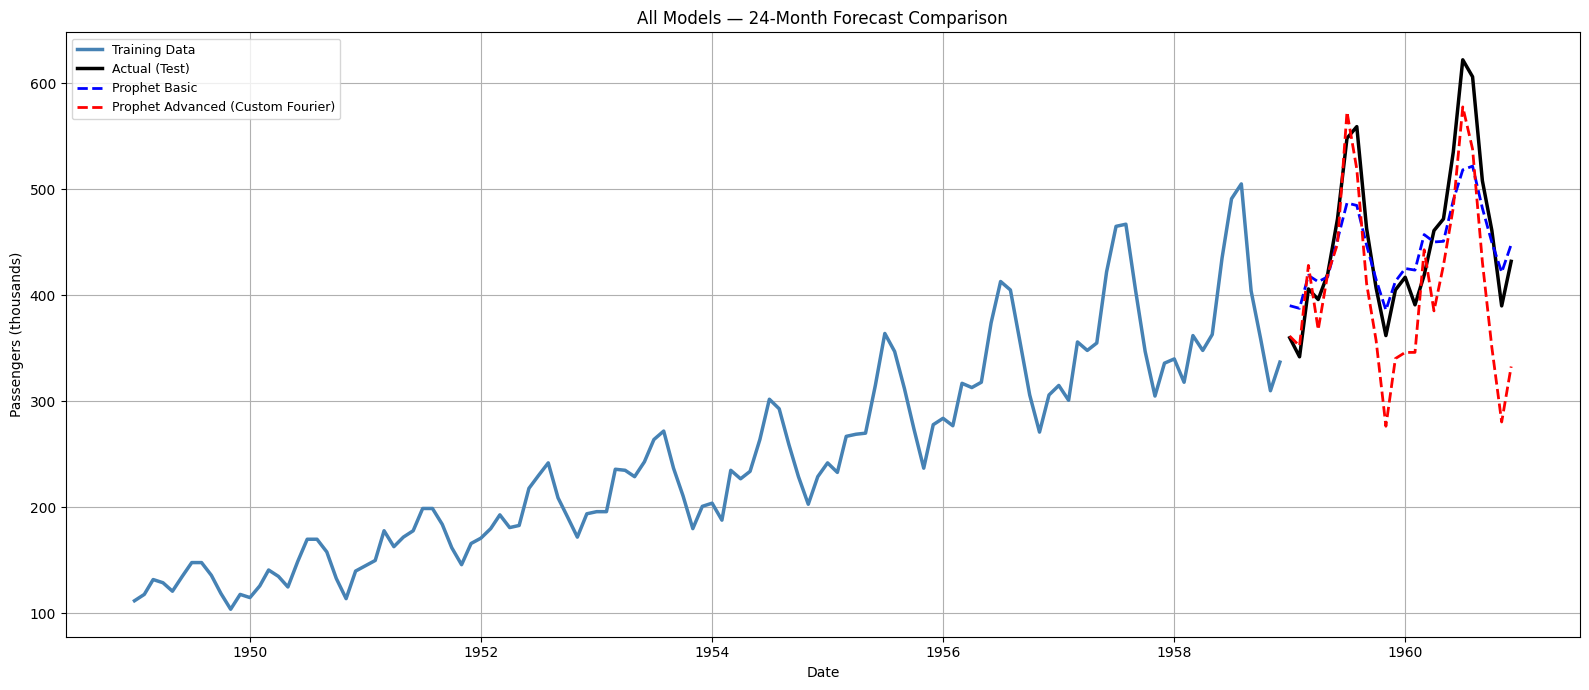

In [54]:
# Overlay all four forecasts on one chart

plt.figure(figsize=(16, 7))

# Training data
plt.plot(train_df['ds'], train_df['y'],
         label='Training Data', color='steelblue', linewidth=2.5)

# Actual test values
plt.plot(test_df['ds'], test_df['y'],
         label='Actual (Test)', color='black', linewidth=2.5)

# Basic Prophet
plt.plot(test_df['ds'], basic_predictions,
         label='Prophet Basic', color='blue', linewidth=2, linestyle='--')

# Advanced Prophet
plt.plot(test_df['ds'], advanced_predictions,
         label='Prophet Advanced (Custom Fourier)', color='red', linewidth=2, linestyle='--')

plt.title('All Models — 24-Month Forecast Comparison')
plt.xlabel('Date')
plt.ylabel('Passengers (thousands)')
plt.legend(loc='upper left', fontsize=9)
plt.grid(True)
plt.tight_layout()
plt.show()

---
## Summary — Prophet vs ARIMA vs Exponential Smoothing

### Key differences between the three methods

| Feature | ARIMA | Holt-Winters | Prophet |
|---|---|---|---|
| Type | Statistical | Statistical | Machine learning inspired |
| Handles trend | Yes (differencing) | Yes (beta parameter) | Yes (automatically) |
| Handles seasonality | Yes (seasonal order) | Yes (gamma parameter) | Yes (Fourier terms) |
| Multiple seasonality | Hard to add | Hard to add | Easy to add |
| Missing data | Needs fixing first | Needs fixing first | Handles automatically |
| Confidence intervals | Requires extra steps | Not built in | Built in |
| Parameter selection | Manual (p,d,q) | Manual (α,β,γ) | Mostly automatic |
| Interpretability | Medium | High | High (component plots) |

### When to use Prophet

Prophet tends to work well when:
- Your data has **multiple seasonal patterns** (e.g. yearly AND weekly)
- You have **missing values** or irregular gaps in the data
- You want **automatic changepoint detection** (trend shifts)
- You need **easy confidence intervals** for business presentations
- The dataset is large (months or years of daily data)

### When ARIMA or Holt-Winters may work better

- Very short datasets (Prophet needs enough data to learn seasonal patterns)
- When you need maximum statistical rigour
- When the data has no seasonality (simple ARIMA is faster and simpler)

### What to try next

- Experiment with `changepoint_prior_scale` in Prophet — higher values make the trend more flexible
- Try adding **holiday effects** using `model.add_country_holidays(country_name='US')`
- Apply Prophet to your unit sales data from the Feature Engineering notebook
- Compare models using cross-validation with `prophet.diagnostics.cross_validation()`